In [1]:
import numpy as np
from pyscf import gto, scf, cc
import jax
jax.config.update("jax_enable_x64", True)

####  test H2 monomers ####
a = 2 # bond length in a cluster
d = 10 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 2 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'H'
unit = 'B'
basis = '6-31g'
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis=basis,
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-28-generic', version='#28~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Jul  1 15:50:57 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Tue Aug  4 18:05:13 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 4
[INPUT] num. electrons = 4
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit 

(np.float64(-0.06802032695059909),
 array([[-5.79757924e-05,  3.37910974e-16,  1.49970060e-02,
          4.47673990e-14, -4.39100962e-05, -2.59173040e-16],
        [-1.40077716e-16, -8.99554500e-06,  4.46423151e-14,
         -1.49923325e-02, -1.69878218e-16,  2.80517665e-05]]),
 array([[[[-7.78222137e-02,  3.22529122e-13, -1.10930085e-04,
            4.00570060e-16, -3.01328890e-02,  1.18810396e-13],
          [ 3.22529122e-13, -7.64584820e-02,  6.83051727e-16,
           -9.68102692e-05,  1.32560141e-13, -3.00991245e-02],
          [-1.10930085e-04,  6.83051727e-16, -1.71160280e-02,
           -7.14439948e-14, -3.29294046e-05,  5.08174302e-16],
          [ 4.00570060e-16, -9.68102692e-05, -7.14439948e-14,
           -1.71014223e-02,  3.62689810e-16, -1.44074340e-05],
          [-3.01328890e-02,  1.32560141e-13, -3.29294046e-05,
            3.62689810e-16, -1.89965860e-02,  7.91120370e-14],
          [ 1.18810396e-13, -3.00991245e-02,  5.08174302e-16,
           -1.44074340e-05,  7.911

In [2]:
from afqmc import t2_tools
t2 =  mycc.t2.transpose(0,2,1,3)
print(t2.shape)
tau = t2_tools.decompose_rt2(t2, 1e-7)
print(tau.shape)

(2, 6, 2, 6)
(6, 2, 6)


In [3]:
import opt_einsum as oe
t2_rec = oe.contract('gia,gjb->iajb', tau, tau, backend='jax')
print(abs(t2_rec - t2).max())

2.9237312307306418e-08


In [4]:
nocc, nvir, _, _ = t2.shape
npair = nocc * nvir
t2_pair = t2.reshape(npair, npair)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_magnitude(M, title="Matrix magnitude", floor=None, cmap="viridis"):
    """
    Plot |M_ij| as a 2D heatmap on a log color scale.

    M : 2D array already paired, e.g. v[(pr),(qs)] or t2[(ia),(jb)],
        OR a 4D tensor which will be reshaped to 2D.
    floor : values with |M| < floor are treated as zero (masked out / shown white).
            Defaults to a small fraction of the max.
    """
    M = np.asarray(M)

    # If it's a 4D tensor v[p,r,q,s] or t2[i,a,j,b], pair the first two
    # and last two indices into a 2D matrix.
    if M.ndim == 4:
        d0, d1, d2, d3 = M.shape
        M = M.reshape(d0 * d1, d2 * d3)

    A = np.abs(M)
    vmax = A.max()
    if floor is None:
        floor = vmax * 1e-8          # anything smaller is "sparse zero"

    # Mask the tiny/zero elements so they render as blank background
    A_masked = np.ma.masked_less(A, floor)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(
        A_masked,
        norm=LogNorm(vmin=floor, vmax=vmax),
        cmap=cmap,
        interpolation="nearest",
        aspect="equal",
    )
    ax.set_title(title)
    ax.set_xlabel("column index  (e.g. qs / jb)")
    ax.set_ylabel("row index  (e.g. pr / ia)")
    fig.colorbar(im, ax=ax, label="|element|")
    plt.tight_layout()
    plt.show()

    # Quick sparsity stat
    nnz = np.count_nonzero(A >= floor)
    print(f"Above floor ({floor:.2e}): {nnz}/{A.size} "
          f"= {100*nnz/A.size:.2f}% of elements")


# --- example usage ---
# Already-paired 2D matrix:
# plot_magnitude(v_pr_qs, title="Two-electron integrals |v_(pr),(qs)|")

# 4D tensor gets paired automatically:
# plot_magnitude(t2, title="CCSD |t2_(ia),(jb)|")   # t2 shape (nocc, nvir, nocc, nvir)

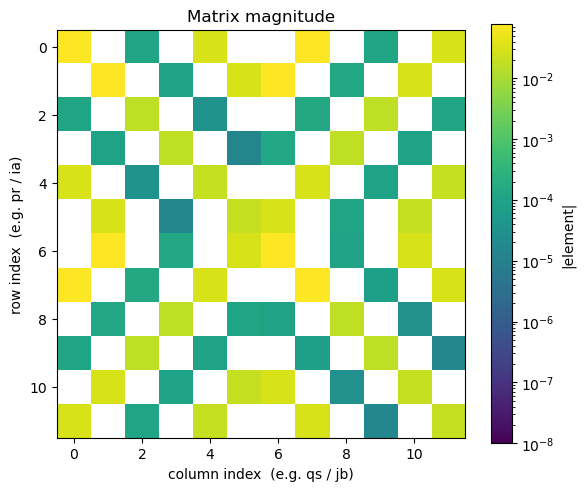

Above floor (1.00e-08): 72/144 = 50.00% of elements


In [6]:
plot_magnitude(t2_pair, floor=1e-8)

In [7]:
from afqmc import prep
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-6)

options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'trial': 'pt2ccsd',
            }

ham_data, ham, prop, trial, wave_data, sampler, options = prep.init_afqmc(options)


Preparing AFQMC calculation
CCSD type input object
Calculating Cholesky integrals
Cholesky shape: (20, 8, 8) 
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [2, 2]
Number of basis functions:  8
Number of Cholesky vectors: 20

QMC Parameters
eql_time        -         10
n_blocks        -        100
n_walkers       -        300
max_error       -          0
mix_precision   -      False
seed            -         17
walker_type     -        rhf
trial           -    pt2ccsd
dt              -      0.005
n_exp_terms     -          6
n_prop_steps    -         50
n_batch         -          1
nchol_chunk     -        100
max_memory      -       2000
free_projection -      False

Load system from Integral File
Maximum memory per walker:            6.67 MB
Maximum number of Cholesky per chunk: 6826
Number of Cholesky chunks:            1
Number of Cholesky per chunk:         20
Number of padding Cholesky:           0

QMC System
Number of electro

In [8]:
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial.get_rdm1(wave_data)
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)
h0 = ham_data['h0']

prop_data = prep.init_hf_prop_data(trial, wave_data, ham_data, options)

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])
print(init_e - mf.e_tot)


Initalize QMC walkers by HF
6.706351030061342e-10


In [9]:
wave_data["tau"] = t2_tools.decompose_rt2(wave_data["t2"], 1e-7)
print(wave_data["tau"].shape)
print(f"rank reduction: {wave_data["t2"].shape[0]*wave_data["t2"].shape[1]} -> {wave_data["tau"].shape[0]}")

(6, 2, 6)
rank reduction: 12 -> 6


In [10]:
prop_data["key"]

Array([ 0, 17], dtype=uint32)

In [11]:
from jax import numpy as jnp
from afqmc import slater_tools, cc_tools

nocc, norb = trial.nelec[0], trial.norb
mo = jnp.eye(norb)[:,:nocc]
mo_t1 = slater_tools.thouless(mo, wave_data["t1"])

In [12]:
h0 = ham_data["h0"]
h1 = ham_data["h1"][0]
chol = ham_data["chol"].reshape(-1, norb, norb)

In [13]:
print(mycc.energy(mycc.t1, mycc.t2*0))
print(slater_tools.r_energy(mo, mo_t1, h0, h1, chol)-mf.e_tot)

4.108337684531167e-05
(4.1084007152303315e-05+0j)


In [14]:
print(mycc.e_tot)

-2.235633381770743


In [16]:
# nslater = 10
# nsample = 1000
# estocc_sp = np.zeros(nsample, dtype=np.complex128)
# ostocc_sp = np.zeros(nsample, dtype=np.complex128)

# for i in range(nsample):
#     wave_data["stocc"], prop_data["key"] = \
#         cc_tools.get_stoccsd(mo_t1, wave_data["tau"], nslater, prop_data["key"])
#     estocc_sp[i] = slater_tools.rms_energy(wave_data["stocc"], mo, h0, h1, chol)
#     ostocc_sp[i] = slater_tools.rms_overlap(wave_data["stocc"], mo)
#     estocc = np.sum(ostocc_sp * estocc_sp) / np.sum(ostocc_sp)
#     print(estocc)

def weighted_mean_and_error(w, e):
    """Ratio estimator R = Σwe/Σw and jackknife std-error of its real part.
       w = overlaps, e = local energies (both complex)."""
    w = np.asarray(w); e = np.asarray(e)
    Sw, Swe = w.sum(), (w * e).sum()
    R = Swe / Sw
    n = len(w)
    R_loo = (Swe - w * e) / (Sw - w)          # leave-one-out ratios, vectorized
    var_jk = (n - 1) / n * np.sum((R_loo.real - R_loo.real.mean())**2)
    return R, np.sqrt(var_jk)


nslater = 100
nsample = 100
nprint  = 20
print_every = nsample // nprint               # -> 50

estocc_sp = np.zeros(nsample, dtype=np.complex128)
ostocc_sp = np.zeros(nsample, dtype=np.complex128)

for i in range(nsample):
    wave_data["slaters"], prop_data["key"] = \
        cc_tools.get_stoccsd(mo_t1, wave_data["tau"], nslater, prop_data["key"])
    estocc_sp[i] = slater_tools.rms_energy(wave_data["slaters"], mo, h0, h1, chol)
    ostocc_sp[i] = slater_tools.rms_overlap(wave_data["slaters"], mo)

    if (i + 1) % print_every == 0:
        R, err = weighted_mean_and_error(ostocc_sp[:i+1], estocc_sp[:i+1])
        print(f"n = {i+1:5d}   E = {R.real:.8f} +/- {err:.8f}   "
              f"(Im = {R.imag:+.2e})")

n =     5   E = -2.23824987 +/- 0.00307142   (Im = +7.64e-06)
n =    10   E = -2.23746083 +/- 0.00169864   (Im = -1.49e-05)
n =    15   E = -2.23647176 +/- 0.00123193   (Im = -2.75e-05)
n =    20   E = -2.23646771 +/- 0.00103655   (Im = -1.80e-05)
n =    25   E = -2.23611723 +/- 0.00089785   (Im = -1.79e-05)
n =    30   E = -2.23588992 +/- 0.00080347   (Im = -1.29e-05)
n =    35   E = -2.23579352 +/- 0.00071190   (Im = -7.56e-06)
n =    40   E = -2.23610305 +/- 0.00067611   (Im = -2.76e-06)
n =    45   E = -2.23603279 +/- 0.00068551   (Im = -8.05e-06)
n =    50   E = -2.23545914 +/- 0.00067600   (Im = -5.68e-06)
n =    55   E = -2.23590196 +/- 0.00076348   (Im = -1.26e-05)
n =    60   E = -2.23565461 +/- 0.00072587   (Im = -6.68e-06)
n =    65   E = -2.23545488 +/- 0.00072651   (Im = -6.53e-06)
n =    70   E = -2.23557255 +/- 0.00070065   (Im = -7.67e-06)
n =    75   E = -2.23563100 +/- 0.00068442   (Im = -7.19e-06)
n =    80   E = -2.23566319 +/- 0.00066834   (Im = -1.01e-05)
n =    8

In [ ]:
from afqmc.wavefunctions import rms_wfn
rms_wfn.overlap(trial, , wave_data)